In [1]:
# Importamos las librerias necesarias
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

# Cargmaos el dataset
automobile = pd.read_csv('Automobile_data.csv')
automobile.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [2]:
# Vemos el tipo de cada columna
automobile.dtypes

# Vemos la estadistica del dataset
automobile.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [3]:
# Limpiamos la data

In [4]:
# Revisamos los nulos
automobile.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [5]:
# Felizmente no hay nulos, pero desde el primer momento
# vimos que la columna normalized-losses estaba sucia, 
# asi que contamos cuantas filas estan afectadas
automobile['normalized-losses'].loc[automobile['normalized-losses']=='?'].count()

np.int64(41)

In [6]:
# Reemplazamos esos valores desconocidos
# Primero convertimos a numerico para analizar outliers
nl = automobile['normalized-losses'].loc[automobile['normalized-losses'] != '?']
nl_numeric = nl.astype(str).astype(int)

# Verificamos outliers usando IQR
Q1 = nl_numeric.quantile(0.25)
Q3 = nl_numeric.quantile(0.75)
IQR = Q3 - Q1
outliers_exist = ((nl_numeric < (Q1 - 1.5 * IQR)) | (nl_numeric > (Q3 + 1.5 * IQR))).any()

# Si hay outliers, usamos mediana; si no, usamos media
if outliers_exist:
    nl_impute = nl_numeric.median()
    print(f"Outliers detectados en normalized-losses. Usando mediana: {nl_impute}")
else:
    nl_impute = nl_numeric.mean()
    print(f"No hay outliers en normalized-losses. Usando media: {nl_impute}")

automobile['normalized-losses'] = automobile['normalized-losses'].replace('?', nl_impute).astype(int)
automobile.head()

Outliers detectados en normalized-losses. Usando mediana: 115.0


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,115,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,115,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [7]:
# Revisamos el numero de valores que no es numerico en los precios
automobile['price'].str.isnumeric().value_counts()

price
True     201
False      4
Name: count, dtype: int64

In [8]:
# Mostramos esos valores
automobile['price'].loc[automobile['price'].str.isnumeric()== False]

9      ?
44     ?
45     ?
129    ?
Name: price, dtype: object

In [9]:
# Reemplazamos esos valores por la media o mediana dependiendo de outliers
price = automobile['price'].loc[automobile['price'] != '?']
price_numeric = price.astype(str).astype(int)

# Verificamos outliers usando IQR
Q1 = price_numeric.quantile(0.25)
Q3 = price_numeric.quantile(0.75)
IQR = Q3 - Q1
outliers_exist = ((price_numeric < (Q1 - 1.5 * IQR)) | (price_numeric > (Q3 + 1.5 * IQR))).any()

# Si hay outliers, usamos mediana; si no, usamos media
if outliers_exist:
    price_impute = price_numeric.median()
    print(f"Outliers detectados en price. Usando mediana: {price_impute}")
else:
    price_impute = price_numeric.mean()
    print(f"No hay outliers en price. Usando media: {price_impute}")

automobile['price'] = automobile['price'].replace('?', price_impute).astype(int)
automobile['price'].head()

Outliers detectados en price. Usando mediana: 10295.0


0    13495
1    16500
2    16500
3    13950
4    17450
Name: price, dtype: int64

In [10]:
# Revisamos los numericos y reemplazamos con la media o mediana según outliers
automobile['horsepower'].str.isnumeric().value_counts()
horsepower = automobile['horsepower'].loc[automobile['horsepower'] != '?']
hp_numeric = horsepower.astype(str).astype(int)

# Verificamos outliers usando IQR
Q1 = hp_numeric.quantile(0.25)
Q3 = hp_numeric.quantile(0.75)
IQR = Q3 - Q1
outliers_exist = ((hp_numeric < (Q1 - 1.5 * IQR)) | (hp_numeric > (Q3 + 1.5 * IQR))).any()

# Si hay outliers, usamos mediana; si no, usamos media
if outliers_exist:
    hp_impute = hp_numeric.median()
    print(f"Outliers detectados en horsepower. Usando mediana: {hp_impute}")
else:
    hp_impute = hp_numeric.mean()
    print(f"No hay outliers en horsepower. Usando media: {hp_impute}")

# CORREGIDO: Usamos hp_impute (no pmean!)
automobile['horsepower'] = automobile['horsepower'].replace('?', hp_impute).astype(int)

Outliers detectados en horsepower. Usando mediana: 95.0


<Axes: ylabel='horsepower'>

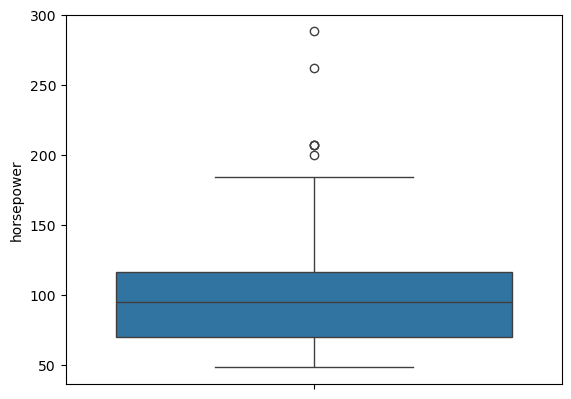

In [11]:
# Revisamos el outlier de horsepower
fig = plt.figure()
sns.boxplot(data=automobile['horsepower'])

In [12]:
# Usamos IQR (Inter Quartile Range) para detectar outliers en lugar de desviación estándar
Q1 = automobile['horsepower'].quantile(0.25)
Q3 = automobile['horsepower'].quantile(0.75)
IQR = Q3 - Q1

# Outliers son valores fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Límite inferior: {lower_bound}")
print(f"Límite superior: {upper_bound}")

# Filtramos outliers
automobile_sin_outliers = automobile[
    (automobile['horsepower'] >= lower_bound) & 
    (automobile['horsepower'] <= upper_bound)
]

print(f"\nFilas originales: {len(automobile)}")
print(f"Filas sin outliers: {len(automobile_sin_outliers)}")
print(f"Outliers removidos: {len(automobile) - len(automobile_sin_outliers)}")

automobile_sin_outliers

Límite inferior: 1.0
Límite superior: 185.0

Filas originales: 205
Filas sin outliers: 199
Outliers removidos: 6


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,115,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,115,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [13]:
# Revisamos los valores de bore
automobile['bore'].loc[automobile['bore'] == '?']

55    ?
56    ?
57    ?
58    ?
Name: bore, dtype: object

In [14]:
automobile['bore'] = pd.to_numeric(automobile['bore'],errors='coerce')
automobile.dtypes

symboling              int64
normalized-losses      int64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke                object
compression-ratio    float64
horsepower             int64
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

In [15]:
automobile['stroke'] = pd.to_numeric(automobile['stroke'],errors='coerce')
automobile.dtypes

symboling              int64
normalized-losses      int64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

In [16]:
automobile['peak-rpm'] = pd.to_numeric(automobile['peak-rpm'],errors='coerce')
automobile.dtypes

symboling              int64
normalized-losses      int64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

In [17]:
print(automobile['num-of-doors'].loc[automobile['num-of-doors'] == '?'])
automobile = automobile[automobile['num-of-doors'] != '?']
automobile['num-of-doors'].loc[automobile['num-of-doors'] == '?']

27    ?
63    ?
Name: num-of-doors, dtype: object


Series([], Name: num-of-doors, dtype: object)

In [18]:
# Realizamos el analisis univariado del dataset

Text(0.5, 0, 'Marca')

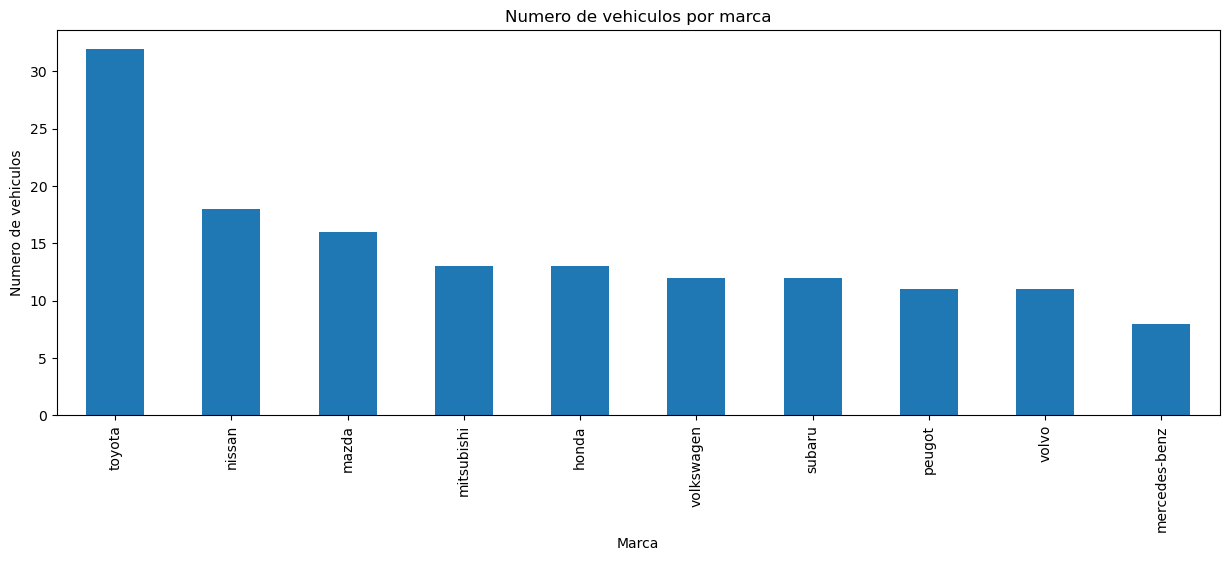

In [19]:
# Frecuencia de la columna make
automobile.make.value_counts().nlargest(10).plot(kind='bar', figsize=(15,5))
plt.title("Numero de vehiculos por marca")
plt.ylabel('Numero de vehiculos')
plt.xlabel('Marca')

Text(0.5, 0, 'Risk rating')

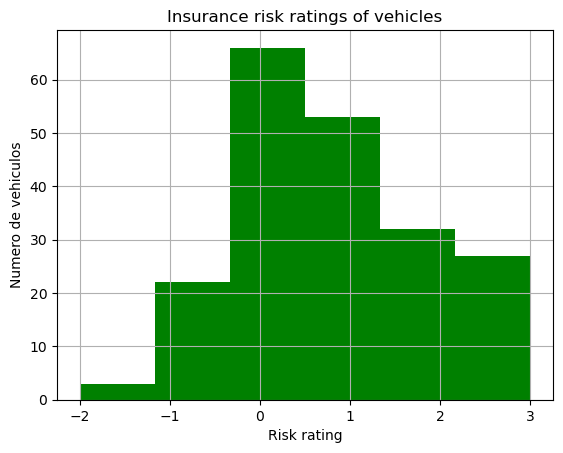

In [20]:
# Histograma de Risk rating
automobile.symboling.hist(bins=6,color='green')
plt.title("Insurance risk ratings of vehicles")
plt.ylabel('Numero de vehiculos')
plt.xlabel('Risk rating')

Text(0.5, 0, 'Normalized losses')

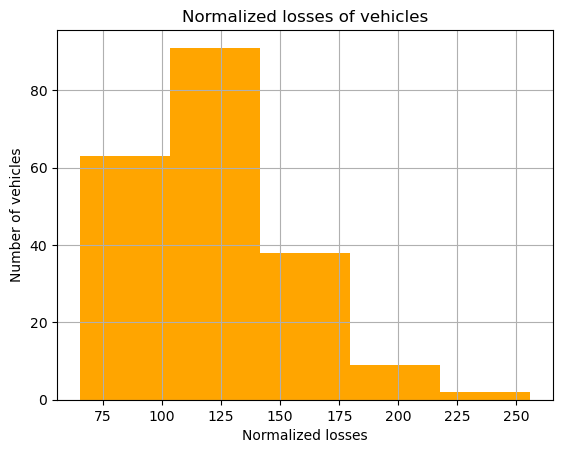

In [21]:
# Histograma de Normalized-losses
automobile['normalized-losses'].hist(bins=5,color='orange');
plt.title("Normalized losses of vehicles")
plt.ylabel('Number of vehicles')
plt.xlabel('Normalized losses')

Text(0.5, 0, 'Tipo de combustible')

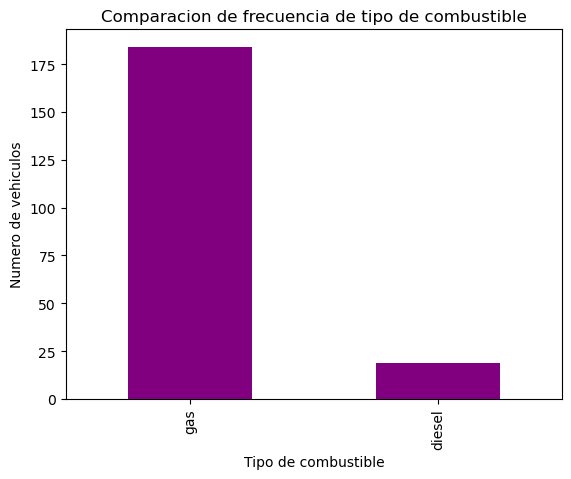

In [22]:
# Comparacion del tipo de combustible
automobile['fuel-type'].value_counts().plot(kind='bar',color='purple')
plt.title("Comparacion de frecuencia de tipo de combustible")
plt.ylabel('Numero de vehiculos')
plt.xlabel('Tipo de combustible')

Text(0.5, 0, 'Caballos de fuerza')

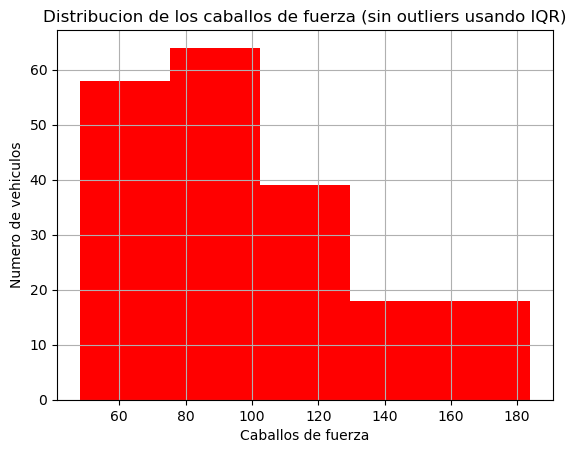

In [23]:
# Histograma de caballos de fuerza (usando IQR para filtrar outliers)
Q1 = automobile['horsepower'].quantile(0.25)
Q3 = automobile['horsepower'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

automobile['horsepower'][
    (automobile['horsepower'] >= lower_bound) & 
    (automobile['horsepower'] <= upper_bound)
].hist(bins=5, color='red')

plt.title("Distribucion de los caballos de fuerza (sin outliers usando IQR)")
plt.ylabel('Numero de vehiculos')
plt.xlabel('Caballos de fuerza')

Text(0.5, 0, 'Tipo de traccion')

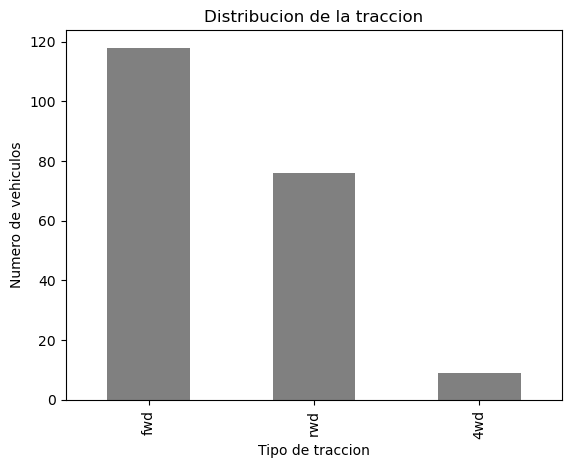

In [24]:
# Distribucion del tipo de traccion
automobile['drive-wheels'].value_counts().plot(kind='bar',color='grey')
plt.title("Distribucion de la traccion")
plt.ylabel('Numero de vehiculos')
plt.xlabel('Tipo de traccion')

In [25]:
# Conclusiones:
# 1. Toyota es la marca que ocupa mas campo en el 
# mercado con mas del 40%, le sigue Nissan
# 2. La traccion fwd (Front wheel drive) tiene la cantidad
# de autos, le sigue rwd 
# 3. La perdida normalizada (normalized-losses), que es el pago 
# promedio por perdida por cada año que un vehiculo esta asegurado, 
# tiene la mayor cantidad de automoviles en el rango de 65 y 150

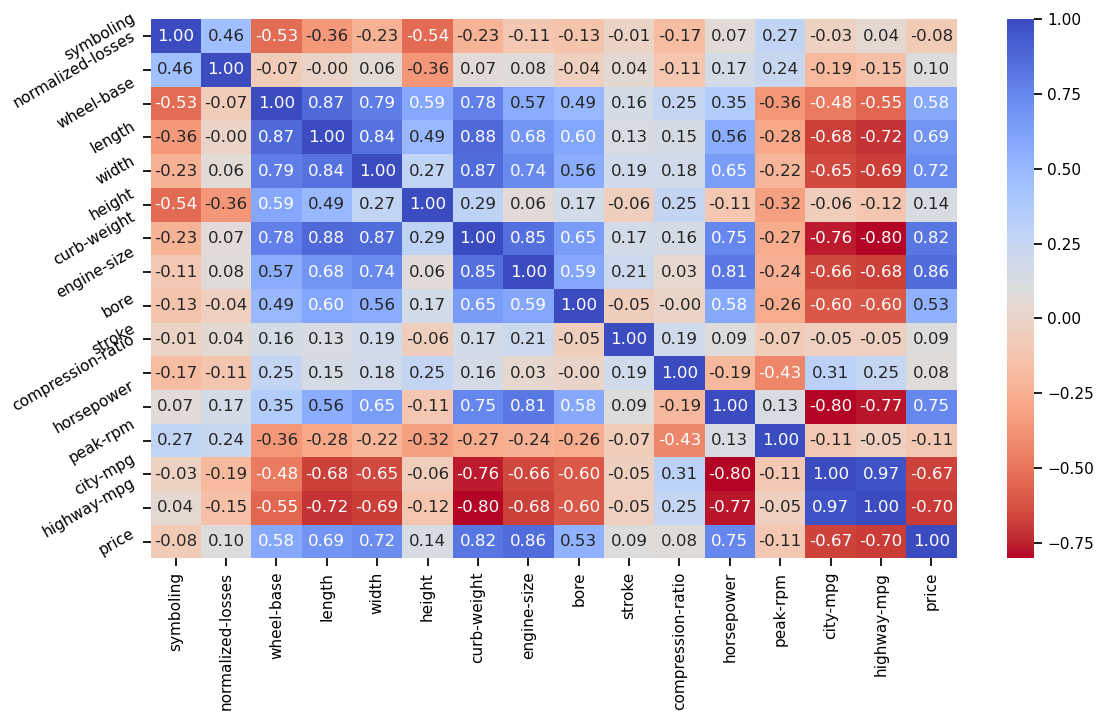

In [26]:
# Analisis de Correlacion (Heatmap)
corr = automobile.select_dtypes(include=['number']).corr()
sns.set_context("notebook", font_scale=1.0, rc={"lines.linewidth": 2.5})
plt.figure(figsize=(13,7))
a = sns.heatmap(corr, annot=True, fmt='.2f',cmap='coolwarm_r')
rotx = a.set_xticklabels(a.get_xticklabels(), rotation=90)
roty = a.set_yticklabels(a.get_yticklabels(), rotation=30)

In [27]:
# Analisis Bivariado

C:\Users\dario\AppData\Local\Temp\ipykernel_10788\399652971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="make", y="price", data=automobile,palette='pastel')


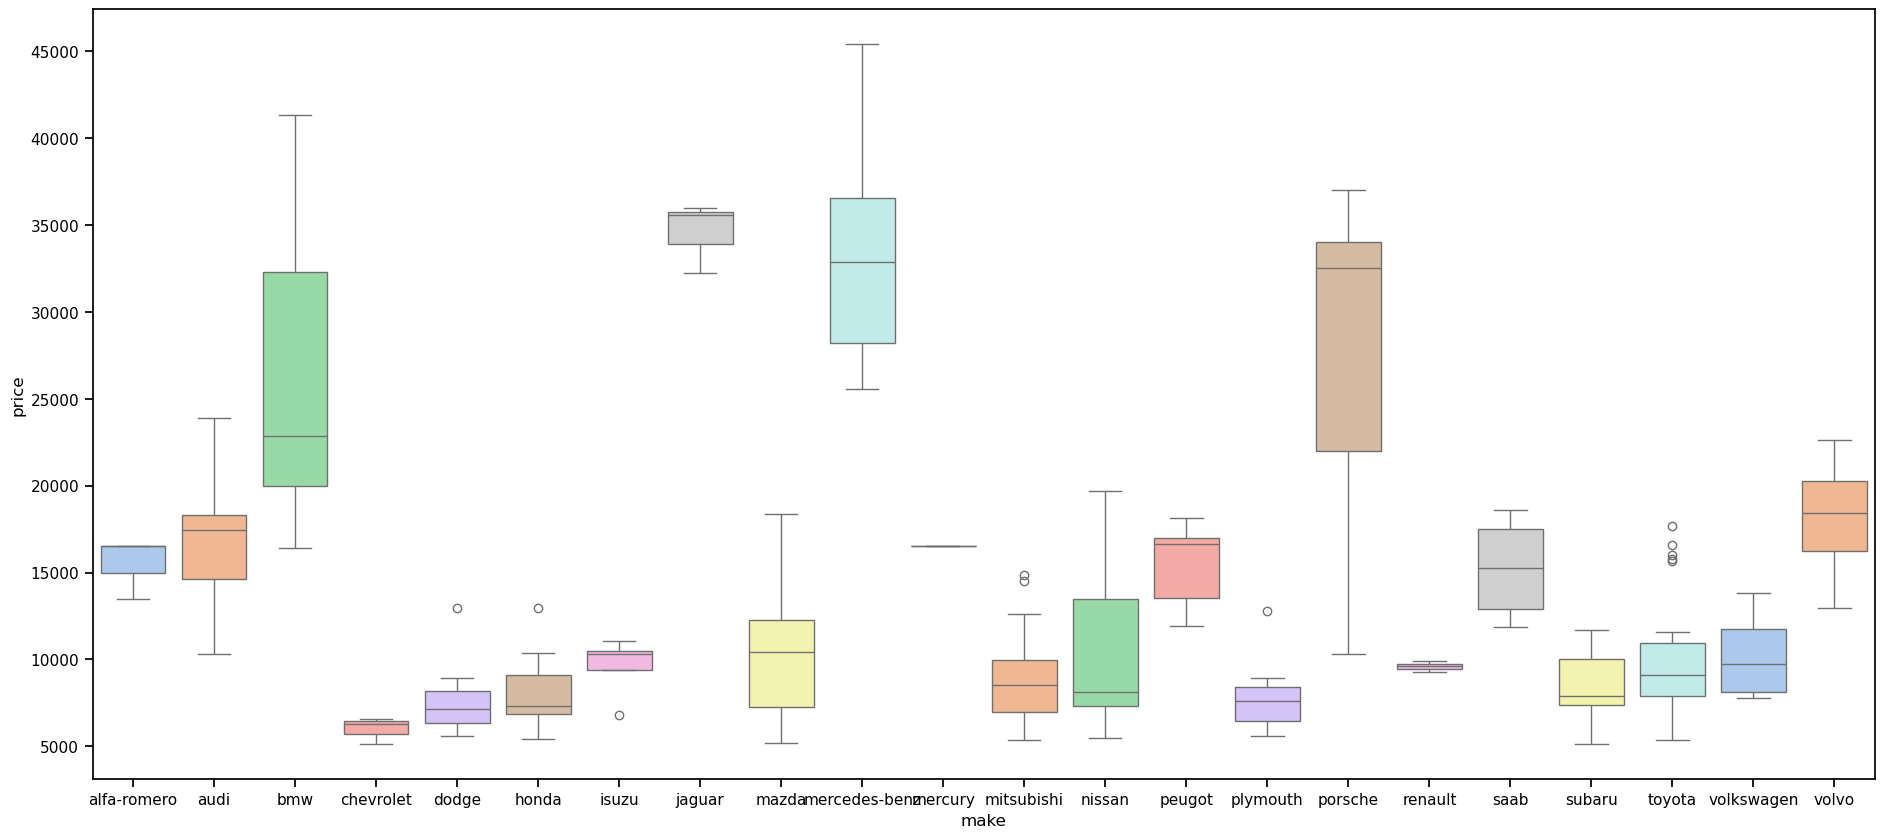

In [28]:
# Boxplot de marca por precio
plt.rcParams['figure.figsize']=(23,10)
ax = sns.boxplot(x="make", y="price", data=automobile,palette='pastel')

In [29]:
# De este grafico concluimos que existen 3 tipos de marca
# Marcas de Lujo (Precio sobre 20000 dolares)
# Marcas Premium (Precio entre 10000 y 20000 dolares)
# Marcas Economicas (Precio debajo de 10000 dolares)
# El siguiente paso sera clasificar las marcas y adjuntarla al dataset

In [30]:
# Calculamos la mediana
mediana_precios = automobile.groupby('make')['price'].median()

# Creamos una funcion para clasificar estas marcas
def clasificar_marca(precio):
    if precio > 20000:
        return 'Lujo'
    elif 10000 <= precio <= 20000:
        return 'Premium'
    else:
        return 'Económico'

# Creamos un diccionario con el segmento de cada marca
segmentos_por_marca = {marca: clasificar_marca(precio) for marca, precio in mediana_precios.items()}

# Mapeamos la informacion al dataset
automobile['segmento'] = automobile['make'].map(segmentos_por_marca)

# Vemos los cambios
automobile.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,segmento
0,3,115,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,27,13495,Premium
1,3,115,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,27,16500,Premium
2,1,115,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000.0,19,26,16500,Premium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500.0,24,30,13950,Premium
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500.0,18,22,17450,Premium


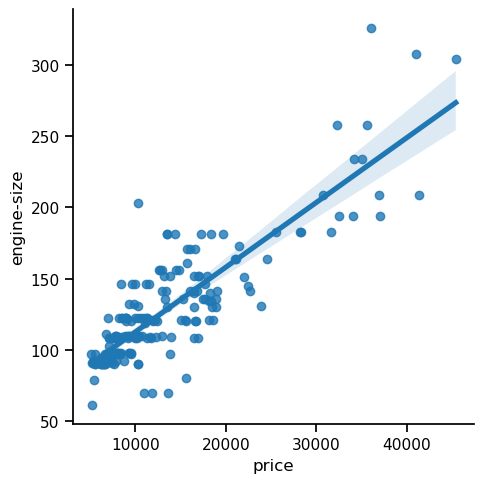

In [31]:
# Graficamos un scatterplot entre el precio y engine-size
sns.lmplot(data=automobile,x='price',y='engine-size')

In [32]:
# A mayor precio mayor engine-size

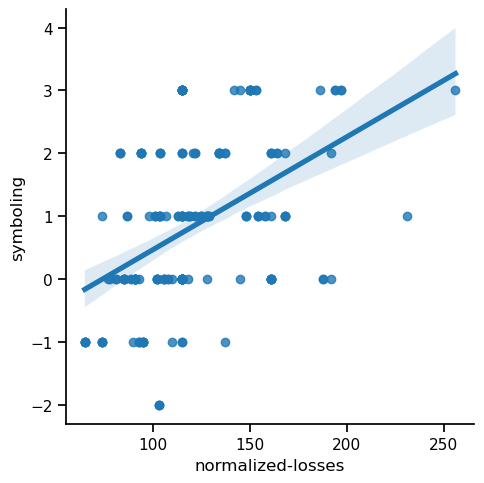

In [33]:
# Normalized-losses vs symboling
sns.lmplot(data=automobile,x='normalized-losses',y='symboling')

In [34]:
# A menor normalized-losses, menor symboling

Text(0.5, 0, 'Drive wheels')

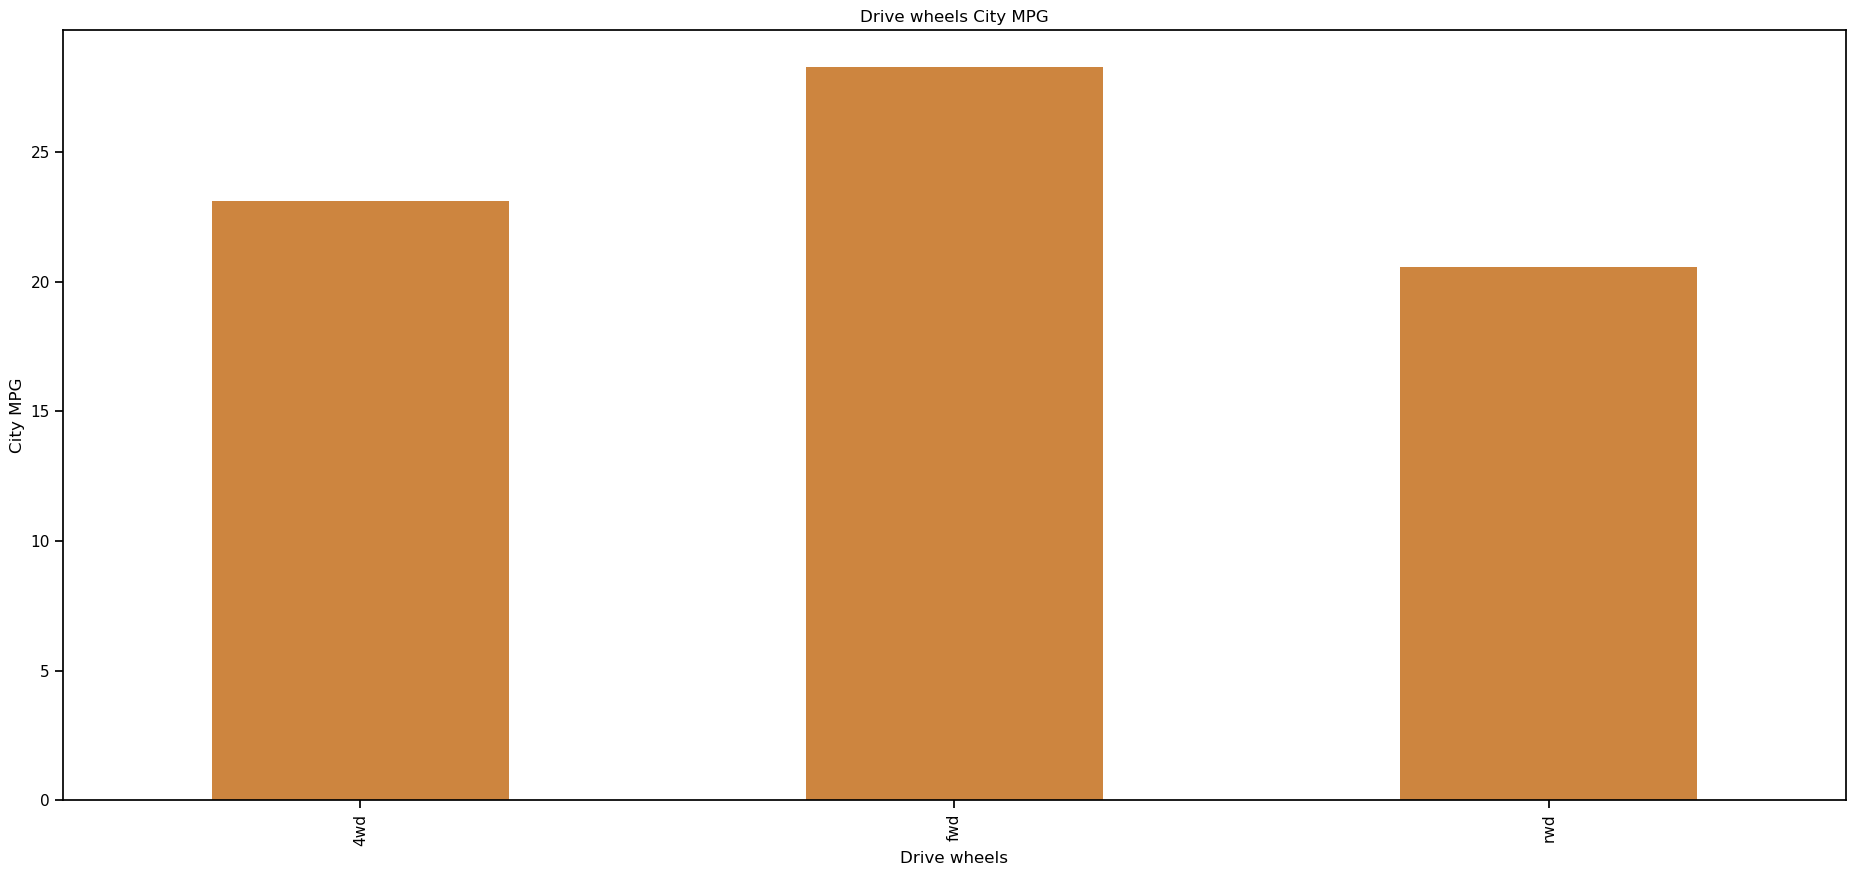

In [35]:
# Ahora veremos cual es la traccion que mas MPG consume
# En la ciudad
automobile.groupby('drive-wheels')['city-mpg'].mean().plot(kind='bar', color = 'peru');
plt.title("Drive wheels City MPG")
plt.ylabel('City MPG')
plt.xlabel('Drive wheels')

Text(0.5, 0, 'Drive wheels')

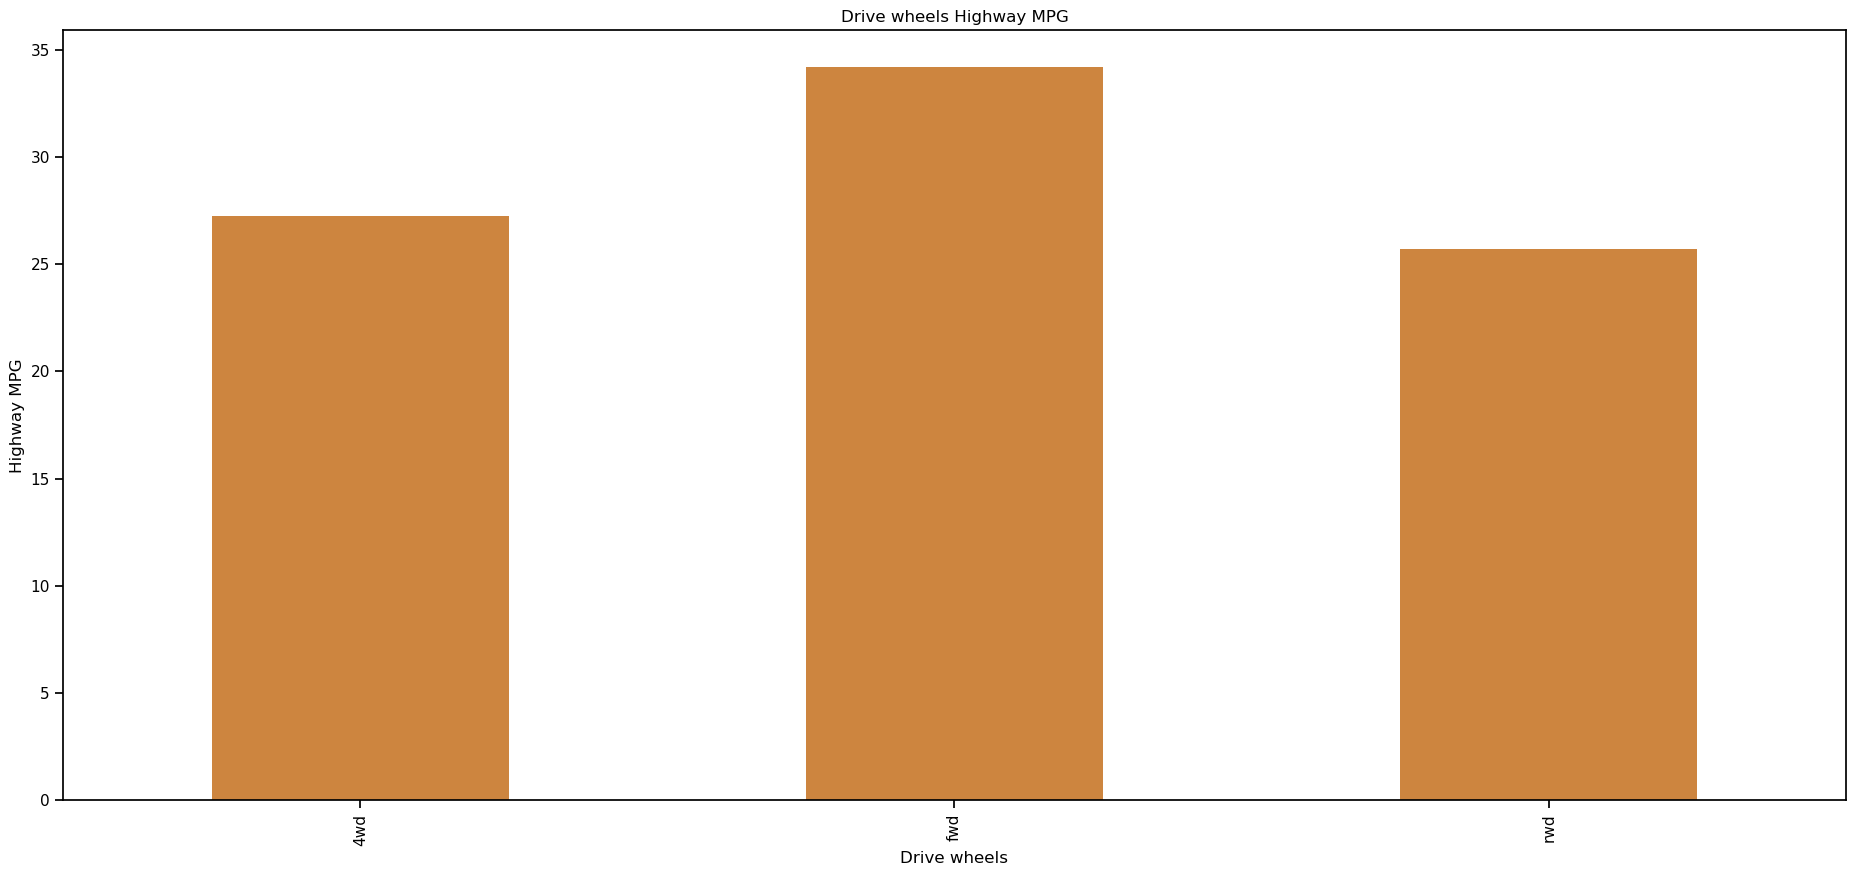

In [36]:
# En la carretera
automobile.groupby('drive-wheels')['highway-mpg'].mean().plot(kind='bar', color = 'peru');
plt.title("Drive wheels Highway MPG")
plt.ylabel('Highway MPG')
plt.xlabel('Drive wheels')

C:\Users\dario\AppData\Local\Temp\ipykernel_10788\3304128296.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='drive-wheels', y='price',data=automobile,palette='viridis')


<Axes: xlabel='drive-wheels', ylabel='price'>

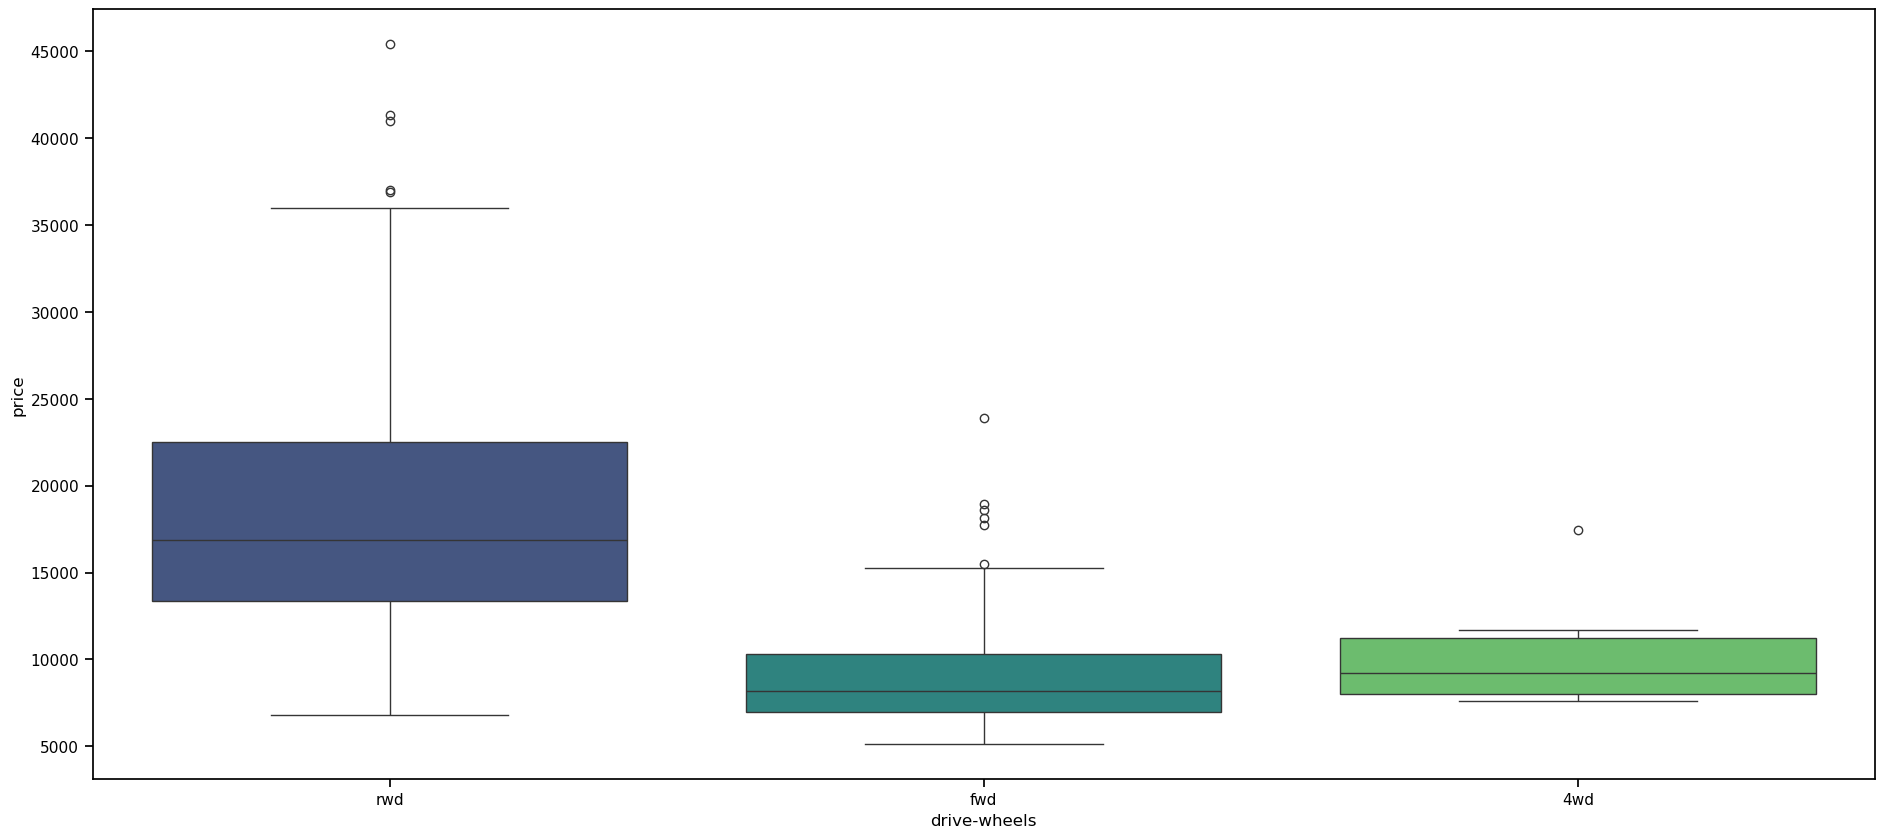

In [37]:
# Analicemos cual es el tipo de traccion mas caro
sns.boxplot(x='drive-wheels', y='price',data=automobile,palette='viridis')

In [38]:
# Exportamos el dataset limpio como excel para presentarlo en power BI
automobile.to_excel('Dataset_limpio.xlsx')